#### 현재 위치 확인

In [1]:
%pwd

'c:\\Users\\ADMIN\\Documents\\projects\\team\\Dlthon_02\\Jong-ha'

#### 클라이언트 정의

In [2]:
from openai import OpenAI
import os
from dotenv import load_dotenv

load_dotenv()


openai_api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key = openai_api_key)

#### LLM 호출

In [3]:
from langchain_openai import ChatOpenAI


llm = ChatOpenAI(
    model = "gpt-5.4",
    temperature = 0.6,
    max_tokens = 1000
)

small_llm = ChatOpenAI(
    model = "gpt-5.4-mini",
    temperature = 0.6,
    max_tokens = 1000
)

#### 스테이트 정의

In [24]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph import MessagesState


class AgentState(MessagesState):
    
    # 공용
    response: str
    next: str
    reason: str
    
    # 병인님
    ## 질병 관리
    breed: str
    age: int
    weight: int
    conditions: list[str]
    symptom_raw: str
    hospital: str

    ## 의도파악
    behavior: str
    behavior_cycle: int

    # 아인님 - 서비스 관련한 질문이 들어올 때
    latest_claim: str

#### 슈퍼바이저 노드

In [ ]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder


class SuperVisor(BaseModel):
    
    response_reason: str
    next_node: Literal["Agent1", "Agent2", "Agent3", "Agent4", "check_doc_relevance"] # = Field(description="다음 실행 노드를 결정")

router_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system", """
            당신은 라우터 에이전트입니다.
            대화흐름을 검토하여 다음 사항을 수행하고 그 이유를 간단하게 명시하세요.
            1. 사용자가 반려동물의 상태나 건강에 대해서 물으면 check_doc_relevance 노드로 연결하세요.
            2. 사용자가 반려동물의 행동에 대해서 물으면 check_doc_relevance 노드로 연결하세요.
            3. 사용자가 서비스에 대해 물으면 check_doc_relevance 노드로 연결하세요.
            4. 사용자가 그 외의 것에 대해 질문하면 check_doc_relevance 노드로 연결하세요.
            모든 결정에는 간단하고 짧게 이유를 명시하세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

supervisor_llm  = small_llm.with_structured_output(SuperVisor)
router_chain = router_prompt | supervisor_llm

def supervisor(state: AgentState) -> AgentState:
    response = router_chain.invoke({"messages": state["messages"]})
    
    # 몹시 중요한 부분, 랭그래프의 상태 관리 핵심 (왜 딕셔너리 전체를 리턴하지 않는데 스테이트가 이동하는지?)
    return {
        "next": response.next_node,
        "reason": response.response_reason
    }

#### 문서 관련도 검증 노드

In [45]:
class DocRelevanceChecker(BaseModel):
    
    response_reason: str = Field(description="결정에 대한 이유를 명시하세요")
    next_node: Literal["supervisor", "final_agent"]


relevance_checker_prompt = ChatPromptTemplate(
    [
        (
            "system", """
            1. 대화의 흐름을 참고하여, 사용자의 질문과 검색된 문서가 관련이 있는지 검사하세요.
            2. 만약 관련이 전혀 없다면, 슈퍼바이저 노드로 연결하고 그렇게 판단한 이유를 간단히 명시하세요.
            3. 검색된 문서가 없는 경우, final_agent로 보내세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

relevance_checker_llm = small_llm.with_structured_output(DocRelevanceChecker)
relevance_checker_chain = relevance_checker_prompt | relevance_checker_llm

def check_doc_relevance(state: AgentState) -> AgentState:
    response = relevance_checker_chain.invoke({"messages": state["messages"]})

    return {
        "next": response.next_node,
        "reason": response.response_reason
    }

#### 최종 답변 생성 노드

In [54]:
class FinalAnswer(BaseModel):
    
    response: str 
    response_reason: str = Field(description="답변 내용에 대한 이유를 명시하세요.")

final_answer_prompt = ChatPromptTemplate(
    [
        (
            "system", """
            1. 대화의 흐름을 참고하여, 사용자의 질문에 대한 최종 답변을 작성하세요.
            2. 답변 내용에 대한 이유를 간단히 명시하세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

final_answer_llm = llm.with_structured_output(FinalAnswer)
final_answer_chain = final_answer_prompt | final_answer_llm

def final_agent(state: AgentState) -> AgentState:
    response = final_answer_chain.invoke({"messages": state["messages"]})

    return {
        "response": response.response,
        "reason": response.response_reason
    }

#### 노드를 엣지로 연결, 그래프 컴파일

In [55]:
from langgraph.graph import StateGraph, START, END


builder = StateGraph(AgentState)


builder.add_node("supervisor", supervisor)
builder.add_node("check_doc_relevance", check_doc_relevance)
builder.add_node("final_agent", final_agent)


builder.add_edge(START, "supervisor")
builder.add_edge("supervisor", "check_doc_relevance")

builder.add_conditional_edges(
    "check_doc_relevance", 
    lambda state: state["next"],
    {
        "supervisor": "supervisor",
        "final_agent": "final_agent"
    })
    
builder.add_edge("final_agent", END)


workflow = builder.compile()

#### 그래프 도식화

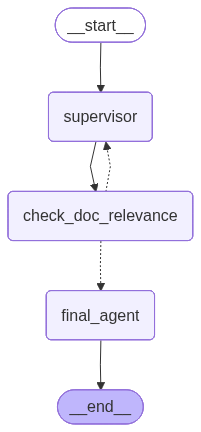

In [56]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [57]:
inputs = {"messages": [("user", "안녕하세요? 반갑습니다. 요즘 어때요? 음식 추천해주세요.")]}

for output in workflow.stream(inputs):
    for key, value in output.items():
        print(f"\n[Node: {key}]")
        print(value)


[Node: supervisor]
{'next': 'check_doc_relevance', 'reason': '음식 추천 요청은 반려동물 상태, 행동, 서비스 문의에 해당하지 않으므로 check_doc_relevance로 연결합니다.'}

[Node: check_doc_relevance]
{'next': 'final_agent', 'reason': '검색된 문서가 제공되지 않았으므로 관련성 검사를 수행할 수 없습니다. 따라서 final_agent로 전달합니다.'}

[Node: final_agent]
{'response': '안녕하세요, 반갑습니다! 저는 항상 잘 지내고 있어요 🙂\n요즘처럼 가볍게 기분 전환하고 싶을 때는 음식으로는 아래를 추천드려요:\n- 매콤한 떡볶이: 스트레스 풀기 좋고 맛있어요.\n- 따뜻한 국밥이나 칼국수: 든든하고 편안한 느낌을 줘요.\n- 초밥이나 덮밥: 깔끔하게 한 끼 먹기 좋아요.\n- 치킨과 맥주(또는 음료): 주말 분위기 내기 좋아요.\n- 디저트로는 크로플이나 케이크: 기분 전환에 좋아요.\n\n원하시면 제가\n1) 한식,\n2) 매운 음식,\n3) 배달음식,\n4) 혼밥용\n중에서 취향에 맞춰 더 자세히 추천해드릴게요!', 'reason': '사용자가 인사와 함께 음식 추천을 요청했기 때문에, 먼저 자연스럽게 안부에 답한 뒤 누구나 부담 없이 고를 수 있는 대표적인 음식들을 간단하고 친근하게 추천했습니다. 또한 취향별로 더 구체적인 추천이 가능하도록 선택지를 함께 제안했습니다.'}
